# Cressman Interpolation Deep Dive

This notebook walks through the Cressman distance-weighted interpolation step that forms the core of the high-res pipeline. It mirrors the Fortran program `append_topo_interp_smooth.f90` from the tx2_3 workflow.

## What is Cressman interpolation?

For each ocean model T-cell, we want an estimate of the ocean depth by averaging nearby source pixels. But we don't want to average blindly — pixels that are close to the cell centre should contribute more than distant ones. The Cressman weight function does exactly that:

$$w_k = \left(\frac{L^2 - r_k^2}{L^2 + r_k^2}\right)^{c}$$

where:
- $r_k$ is the great-circle distance from cell centre to source pixel $k$
- $L = \text{smooth\_scl} \times \sqrt{A}$ is the smoothing radius ($A$ = cell area in m²)
- $c$ = `cressman_exp` (default 2)

Only source ocean pixels within $r_k \leq L$ contribute. The final depth estimate is:

$$d_i = \frac{\sum_k w_k \cdot d_k}{\sum_k w_k}$$

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.spatial import cKDTree
from pathlib import Path
import tempfile

from mom6_forge.grid import Grid
from mom6_forge.topo import Topo
from mom6_forge._source_bathy import SourceBathy

plt.rcParams["figure.dpi"] = 120

## 1. Setup

In [2]:
grid = Grid(resolution=2.0, xstart=262.0, lenx=10.0, ystart=20.0, leny=8.0, name="toy")

src_lons = np.arange(260.0, 274.1, 0.1)
src_lats = np.arange(18.0,  30.1, 0.1)
src_lon2d, src_lat2d = np.meshgrid(src_lons, src_lats)

elevation = np.full(src_lon2d.shape, -2000.0)
elevation[(src_lat2d > 26.0) & (src_lon2d < 265.0)] = +50.0
elevation[
    (src_lat2d > 22.0) & (src_lat2d < 24.0) &
    (src_lon2d > 266.0) & (src_lon2d < 268.0)
] = -80.0

tmp_dir = Path(tempfile.mkdtemp())
src_path = tmp_dir / "synthetic_bathy.nc"
xr.Dataset(
    {"elevation": (["lat", "lon"], elevation.astype("float32"))},
    coords={"lon": src_lons, "lat": src_lats},
).to_netcdf(src_path)

topo = Topo(grid, min_depth=5.0, version_control_dir=tmp_dir)
topo.set_flat(1000)
src = SourceBathy(src_path).slice_to_domain(topo)

# Generate mask (needed for Cressman)
mask = topo.generate_mask_ocean_frac(src, nx_sub=5, ny_sub=5)

print("Setup complete.")

Setup complete.


/glade/u/home/manishrv/documents/croc/regional_mom_workflows/mom6_forge/mom6_forge/topo.py:768: RuntimeWarning: Mean of empty slice
  D_mean = np.nanmean(depth_ocean, axis=(-2, -1))
/glade/u/home/manishrv/documents/croc/regional_mom_workflows/mom6_forge/mom6_forge/topo.py:769: RuntimeWarning: All-NaN slice encountered
  D_min = np.nanmin(depth_ocean, axis=(-2, -1))
/glade/u/home/manishrv/documents/croc/regional_mom_workflows/mom6_forge/mom6_forge/topo.py:770: RuntimeWarning: All-NaN slice encountered
  D_max = np.nanmax(depth_ocean, axis=(-2, -1))
/glade/u/home/manishrv/documents/croc/regional_mom_workflows/mom6_forge/mom6_forge/topo.py:771: RuntimeWarning: Mean of empty slice
  D2_mean = np.nanmean(depth_ocean**2, axis=(-2, -1))


## 2. The Cressman weight function

Let's first visualise $w$ as a function of $r/L$ to understand the shape.

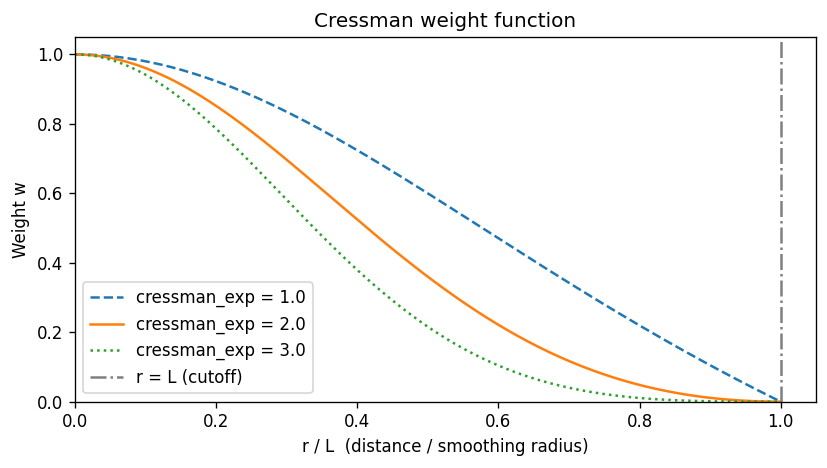

In [3]:
r_over_L = np.linspace(0, 1, 200)

fig, ax = plt.subplots(figsize=(7, 4))
for c_exp, ls in [(1.0, "--"), (2.0, "-"), (3.0, ":")]:
    w = ((1 - r_over_L**2) / (1 + r_over_L**2)) ** c_exp
    ax.plot(r_over_L, w, ls, label=f"cressman_exp = {c_exp}")

ax.axvline(1.0, color="gray", linestyle="-.", label="r = L (cutoff)")
ax.set_xlabel("r / L  (distance / smoothing radius)")
ax.set_ylabel("Weight w")
ax.set_title("Cressman weight function")
ax.legend()
ax.set_xlim(0, 1.05)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

The weight is 1.0 at the cell centre ($r=0$) and 0.0 at the cutoff ($r=L$). Higher `cressman_exp` makes the function more peaked — more weight is given to nearby pixels, and the kernel decays more sharply.

## 3. Smoothing radius $L$ for each cell

$L = \text{smooth\_scl} \times \sqrt{A}$ where $A$ is the T-cell area in m². This means larger cells get a larger search radius, which is physically correct — a coarser model cell should average over more source pixels.

The cell area `DAREA` used in the Fortran is equivalent to `topo._grid.tarea`.

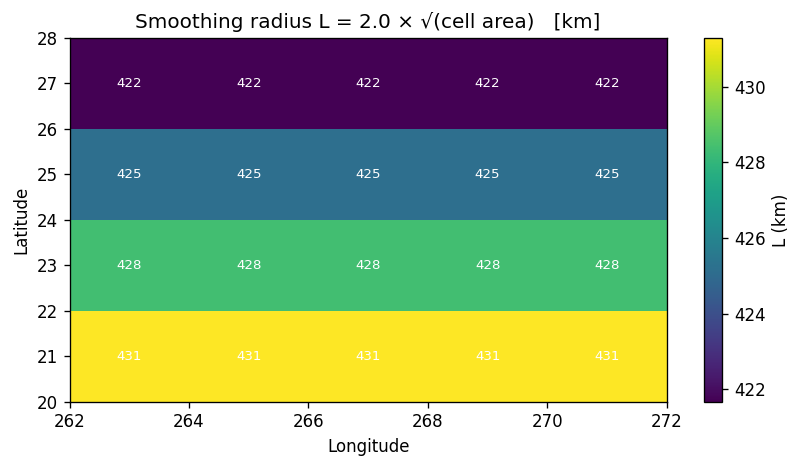

L range: 422 – 431 km
(decreases toward poles as cell area shrinks)


In [4]:
smooth_scl = 2.0
tarea = grid.tarea.values   # cell area in m²
L = smooth_scl * np.sqrt(tarea)   # smoothing radius in m
L_km = L / 1000.0

fig, ax = plt.subplots(figsize=(7, 4))
c = ax.pcolormesh(grid.qlon.values, grid.qlat.values, L_km,
                  cmap="viridis", shading="flat")
plt.colorbar(c, ax=ax, label="L (km)")
for j in range(grid.ny):
    for i in range(grid.nx):
        ax.text(grid.tlon.values[j,i], grid.tlat.values[j,i],
                f"{L_km[j,i]:.0f}",
                ha="center", va="center", fontsize=8, color="white")
ax.set_title(f"Smoothing radius L = {smooth_scl} × √(cell area)   [km]")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

print(f"L range: {L_km.min():.0f} – {L_km.max():.0f} km")
print(f"(decreases toward poles as cell area shrinks)")

## 4. The KDTree — finding source pixels within radius $L$

The Fortran uses a precomputed rectangular patch `(iwid × jwid)` as a bounding box and then tests each pixel in the box for $r \leq L$. The Python implementation replaces this with a **KDTree** built from the 3D Cartesian coordinates of the source ocean pixels.

Why 3D Cartesian? Because `cKDTree.query_ball_point` uses Euclidean (chord) distance, which works globally without any longitude wraparound issues. The chord distance is then converted back to arc (great-circle) distance for the weight calculation.

In [5]:
R = 6_371_000.0  # Earth radius, m

# Build the Cartesian coordinates of source ocean pixels
src_depth = src.depth   # positive-down; ocean > 0
src_lon_2d, src_lat_2d = np.meshgrid(src.lon, src.lat)
is_ocean_src = src_depth > 0

lon_src_rad = np.deg2rad(src_lon_2d.ravel())
lat_src_rad = np.deg2rad(src_lat_2d.ravel())
xyz_src_all = np.stack([
    R * np.cos(lat_src_rad) * np.cos(lon_src_rad),
    R * np.cos(lat_src_rad) * np.sin(lon_src_rad),
    R * np.sin(lat_src_rad),
], axis=1)

# KDTree built ONLY over ocean source pixels
ocean_src_idx = np.where(is_ocean_src.ravel())[0]
tree = cKDTree(xyz_src_all[ocean_src_idx])

print(f"Total source pixels: {src_depth.size}")
print(f"Ocean source pixels in KDTree: {len(ocean_src_idx)}")
print(f"  ({100*len(ocean_src_idx)/src_depth.size:.1f}% of source)")

Total source pixels: 9900
Ocean source pixels in KDTree: 9025
  (91.2% of source)


In [6]:
# For a chosen target cell, show which source pixels are within radius L
jc, ic = 1, 2   # choose a central ocean cell

lon_dst_rad = np.deg2rad(grid.tlon.values[jc, ic])
lat_dst_rad = np.deg2rad(grid.tlat.values[jc, ic])
xyz_dst = np.array([
    R * np.cos(lat_dst_rad) * np.cos(lon_dst_rad),
    R * np.cos(lat_dst_rad) * np.sin(lon_dst_rad),
    R * np.sin(lat_dst_rad),
])

L_cell = smooth_scl * np.sqrt(float(grid.tarea.values[jc, ic]))
print(f"Cell ({jc},{ic}) at lon={grid.tlon.values[jc,ic]:.1f}, lat={grid.tlat.values[jc,ic]:.1f}")
print(f"Smoothing radius L = {L_cell/1000:.1f} km")

# query_ball_point returns indices into tree (= ocean_src_idx)
neighbor_tree_idx = tree.query_ball_point(xyz_dst, L_cell)
neighbor_src_idx  = ocean_src_idx[np.asarray(neighbor_tree_idx)]

# Convert flat source indices back to 2D (lat, lon)
src_ny, src_nx = src_depth.shape
nbr_j = neighbor_src_idx // src_nx
nbr_i = neighbor_src_idx %  src_nx

# Compute arc distances and weights for these neighbors
d_xyz = xyz_src_all[neighbor_src_idx] - xyz_dst
chord  = np.linalg.norm(d_xyz, axis=1)
arc    = 2.0 * R * np.arcsin(np.clip(chord / (2.0 * R), 0, 1))
d2     = arc**2
L2     = L_cell**2
weights = ((L2 - d2) / (L2 + d2)) ** 2.0

print(f"Source ocean pixels within L: {len(neighbor_src_idx)}")
print(f"Weighted depth estimate: {np.sum(weights * src_depth.ravel()[neighbor_src_idx]) / weights.sum():.1f} m")

Cell (1,2) at lon=267.0, lat=23.0
Smoothing radius L = 428.4 km
Source ocean pixels within L: 4987
Weighted depth estimate: 1432.6 m


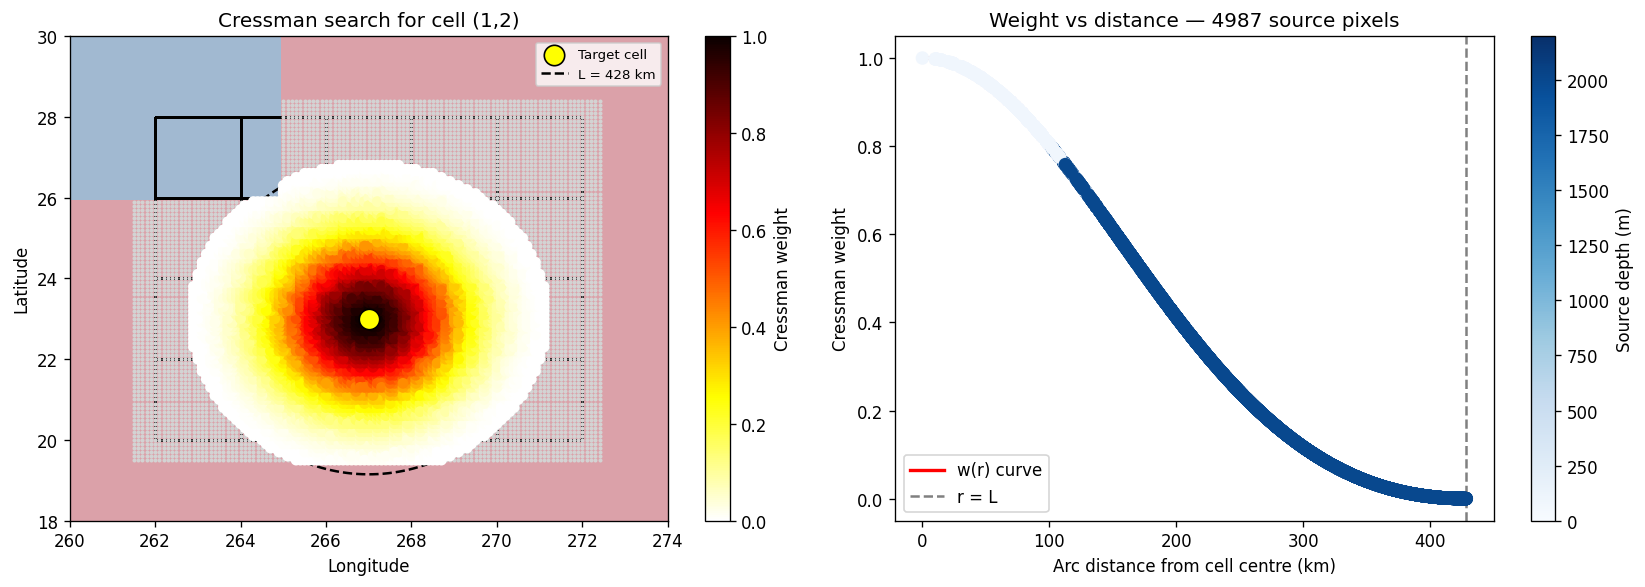

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: source pixels coloured by weight ---
ax = axes[0]
ax.pcolormesh(src_lons, src_lats, elevation,
              cmap="RdBu", vmin=-2200, vmax=200, alpha=0.4, shading="auto")

# All source ocean pixels (small grey dots)
ax.scatter(src_lon_2d.ravel()[ocean_src_idx],
           src_lat_2d.ravel()[ocean_src_idx],
           c="lightgray", s=2, zorder=3)

# Pixels within L coloured by weight
sc = ax.scatter(
    src_lon_2d.ravel()[neighbor_src_idx],
    src_lat_2d.ravel()[neighbor_src_idx],
    c=weights, cmap="hot_r", vmin=0, vmax=1, s=30, zorder=5
)
plt.colorbar(sc, ax=ax, label="Cressman weight")

# Model cell outline and centre
ax.pcolormesh(grid.qlon.values, grid.qlat.values, np.zeros((grid.ny, grid.nx)),
              edgecolors="k", linewidth=0.8, facecolor="none", shading="flat")
ax.scatter(grid.tlon.values[jc, ic], grid.tlat.values[jc, ic],
           c="yellow", s=150, zorder=8, edgecolors="k", label="Target cell")

# Draw the search circle (approximate in lon/lat)
theta = np.linspace(0, 2*np.pi, 200)
deg_per_m = 1.0 / (R * np.pi / 180.0)
circ_lon = grid.tlon.values[jc, ic] + L_cell * deg_per_m * np.cos(theta)
circ_lat = grid.tlat.values[jc, ic] + L_cell * deg_per_m * np.sin(theta)
ax.plot(circ_lon, circ_lat, "k--", lw=1.5, label=f"L = {L_cell/1000:.0f} km")

ax.set_xlim(260, 274)
ax.set_ylim(18, 30)
ax.set_title(f"Cressman search for cell ({jc},{ic})")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(fontsize=8)

# --- Right: weight vs distance scatter ---
ax = axes[1]
arc_km = arc / 1000.0
ax.scatter(arc_km, weights, c=src_depth.ravel()[neighbor_src_idx],
           cmap="Blues", vmin=0, vmax=2200, s=50, zorder=5)
r_plot = np.linspace(0, L_cell / 1000, 200)
r_m = r_plot * 1000
w_curve = ((L2 - r_m**2) / (L2 + r_m**2))**2
ax.plot(r_plot, w_curve, "r-", lw=2, label="w(r) curve")
ax.axvline(L_cell/1000, color="gray", linestyle="--", label="r = L")
ax.set_xlabel("Arc distance from cell centre (km)")
ax.set_ylabel("Cressman weight")
ax.set_title(f"Weight vs distance — {len(neighbor_src_idx)} source pixels")
ax.legend()

sm = plt.cm.ScalarMappable(cmap="Blues", norm=plt.Normalize(0, 2200))
plt.colorbar(sm, ax=axes[1], label="Source depth (m)")

plt.tight_layout()
plt.show()

## 5. The sparse weight matrix

Rather than running the Cressman loop per cell at regrid time, `compute_cressman_weights` builds the entire weight matrix `S` upfront as a **sparse CSR matrix** of shape `(n_dst, n_src)`. Applying the regrid is then just a sparse matrix-vector multiply:

```python
depth_model_flat = S @ depth_source_flat
```

This matrix is also written to an ESMF-compatible netCDF so it can be cached and reused (e.g. for different fields or time steps).

In [8]:
from mom6_forge.mapping import compute_cressman_weights

S, unfilled = compute_cressman_weights(
    dst_lon=grid.tlon.values.ravel(),
    dst_lat=grid.tlat.values.ravel(),
    dst_area=grid.tarea.values.ravel(),
    dst_mask=mask.values.ravel().astype(bool),
    src_lon=src.lon,
    src_lat=src.lat,
    src_ocean_mask=(src.depth > 0),
    smooth_scl=2.0,
    cressman_exp=2.0,
)

print(f"S shape: {S.shape}  (n_dst × n_src)")
print(f"Non-zero entries: {S.nnz}")
print(f"Average non-zeros per ocean row: {S.nnz / int(mask.values.sum()):.1f} source pixels per model cell")
print(f"Unfilled cells: {unfilled.sum()} (will use neighbour fill fallback)")

S shape: (20, 9900)  (n_dst × n_src)
Non-zero entries: 69432
Average non-zeros per ocean row: 3654.3 source pixels per model cell
Unfilled cells: 0 (will use neighbour fill fallback)


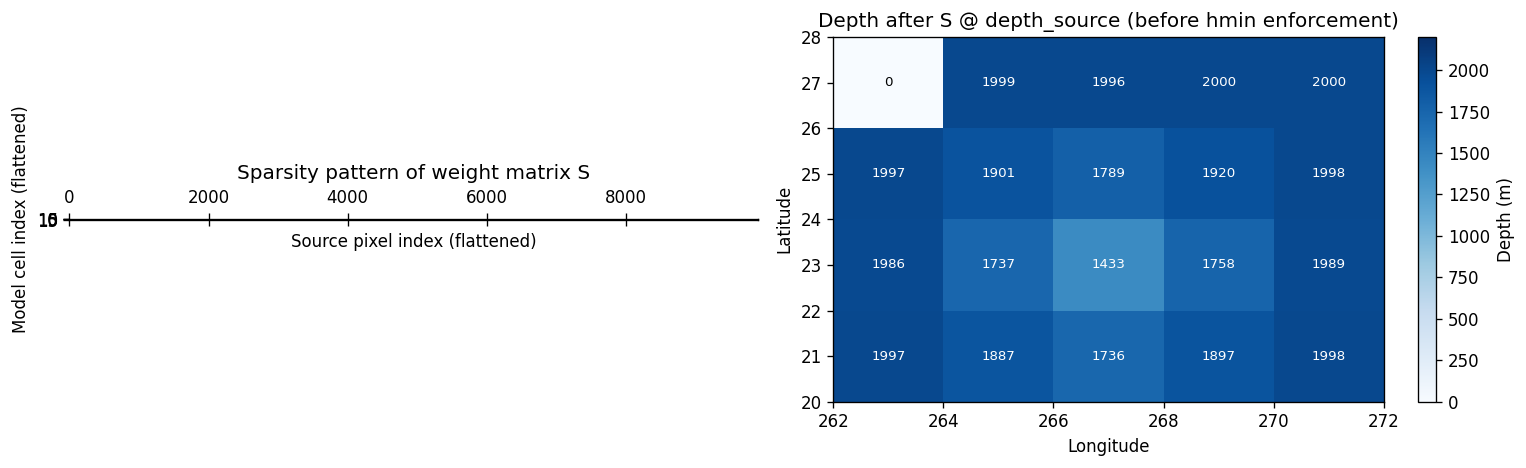

In [9]:
# Visualise the sparsity pattern (each row = one model cell, each col = one source pixel)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.spy(S, markersize=0.5, color="steelblue")
ax.set_xlabel("Source pixel index (flattened)")
ax.set_ylabel("Model cell index (flattened)")
ax.set_title("Sparsity pattern of weight matrix S")

# Apply S to get depth estimates
depth_source_flat = src.depth.ravel().astype(float)
depth_dst_flat = S @ depth_source_flat
depth_dst = depth_dst_flat.reshape(grid.ny, grid.nx)

ax = axes[1]
c = ax.pcolormesh(grid.qlon.values, grid.qlat.values, depth_dst,
                  cmap="Blues", vmin=0, vmax=2200, shading="flat")
plt.colorbar(c, ax=ax, label="Depth (m)")
for j in range(grid.ny):
    for i in range(grid.nx):
        ax.text(grid.tlon.values[j,i], grid.tlat.values[j,i],
                f"{depth_dst[j,i]:.0f}",
                ha="center", va="center", fontsize=8,
                color="white" if depth_dst[j,i] > 500 else "k")
ax.set_title("Depth after S @ depth_source (before hmin enforcement)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()

## 6. Iterative neighbour fill

Some ocean cells may have no source ocean pixels within radius $L$ — typically very small coastal cells. For these, we fall back to averaging from filled neighbours, iterating up to 100 times until all ocean cells have a value.

This is the Python equivalent of the Fortran fallback loop at lines 463–490 of `append_topo_interp_smooth.f90`.

Iterations needed: 1


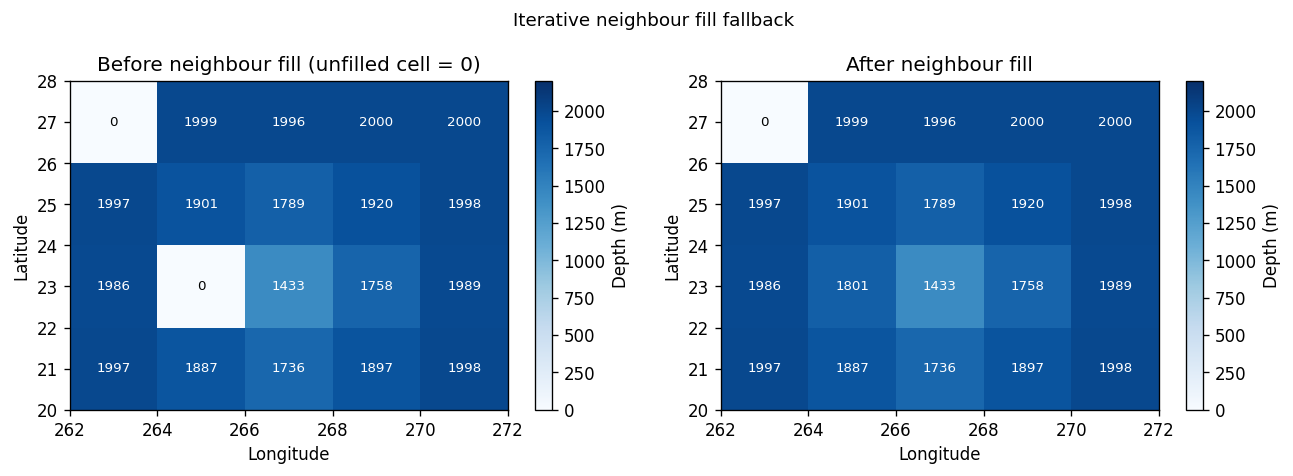

In [10]:
# Simulate a case with an unfilled cell by zeroing it out manually
depth_with_gap = depth_dst.copy()
mask_2d = mask.values.astype(bool)
unfilled_2d = unfilled.reshape(grid.ny, grid.nx) & mask_2d

# For demonstration, manually introduce an unfilled ocean cell
if int(mask.values[1, 1]) == 1:
    unfilled_demo = unfilled_2d.copy()
    unfilled_demo[1, 1] = True
    depth_with_gap[1, 1] = 0.0
else:
    unfilled_demo = unfilled_2d.copy()

depth_filled = depth_with_gap.copy()

iterations_needed = 0
for iteration in range(100):
    if not unfilled_demo.any():
        break
    filled_f = (~unfilled_demo).astype(float)
    d_pad = np.pad(depth_filled, 1, mode="edge")
    f_pad = np.pad(filled_f, 1, mode="constant", constant_values=0)
    d_nbr = (d_pad[:-2,1:-1] + d_pad[2:,1:-1] +
             d_pad[1:-1,:-2] + d_pad[1:-1,2:])
    f_nbr = (f_pad[:-2,1:-1] + f_pad[2:,1:-1] +
             f_pad[1:-1,:-2] + f_pad[1:-1,2:])
    can_fill = unfilled_demo & (f_nbr > 0)
    depth_filled = np.where(can_fill, d_nbr / np.maximum(f_nbr, 1), depth_filled)
    unfilled_demo = unfilled_demo & ~can_fill
    iterations_needed = iteration + 1

print(f"Iterations needed: {iterations_needed}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, data, title in [
    (axes[0], depth_with_gap, "Before neighbour fill (unfilled cell = 0)"),
    (axes[1], depth_filled,   "After neighbour fill"),
]:
    c = ax.pcolormesh(grid.qlon.values, grid.qlat.values, data,
                      cmap="Blues", vmin=0, vmax=2200, shading="flat")
    plt.colorbar(c, ax=ax, label="Depth (m)")
    for j in range(grid.ny):
        for i in range(grid.nx):
            ax.text(grid.tlon.values[j,i], grid.tlat.values[j,i],
                    f"{data[j,i]:.0f}",
                    ha="center", va="center", fontsize=8,
                    color="white" if data[j,i] > 500 else "k")
    ax.set_title(title)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

plt.suptitle("Iterative neighbour fill fallback", fontsize=11)
plt.tight_layout()
plt.show()

## 7. Putting it all together: `cressman_interp`

Computing Cressman weights…
Cressman weights written to /glade/derecho/scratch/manishrv/tmp/tmppx1l48md/cressman_weights.nc


/glade/work/manishrv/conda-envs/mom6_forge/lib/python3.14/site-packages/xesmf/backend.py:42: UserWarning: Input array is not F_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not F_CONTIGUOUS. ' 'Will affect performance.')


Computing Cressman weights…
Cressman weights written to /glade/derecho/scratch/manishrv/tmp/tmppx1l48md/weights_1.0.nc


/glade/work/manishrv/conda-envs/mom6_forge/lib/python3.14/site-packages/xesmf/backend.py:42: UserWarning: Input array is not F_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not F_CONTIGUOUS. ' 'Will affect performance.')


Computing Cressman weights…
Cressman weights written to /glade/derecho/scratch/manishrv/tmp/tmppx1l48md/weights_2.0.nc


/glade/work/manishrv/conda-envs/mom6_forge/lib/python3.14/site-packages/xesmf/backend.py:42: UserWarning: Input array is not F_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not F_CONTIGUOUS. ' 'Will affect performance.')


Computing Cressman weights…
Cressman weights written to /glade/derecho/scratch/manishrv/tmp/tmppx1l48md/weights_4.0.nc


/glade/work/manishrv/conda-envs/mom6_forge/lib/python3.14/site-packages/xesmf/backend.py:42: UserWarning: Input array is not F_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not F_CONTIGUOUS. ' 'Will affect performance.')


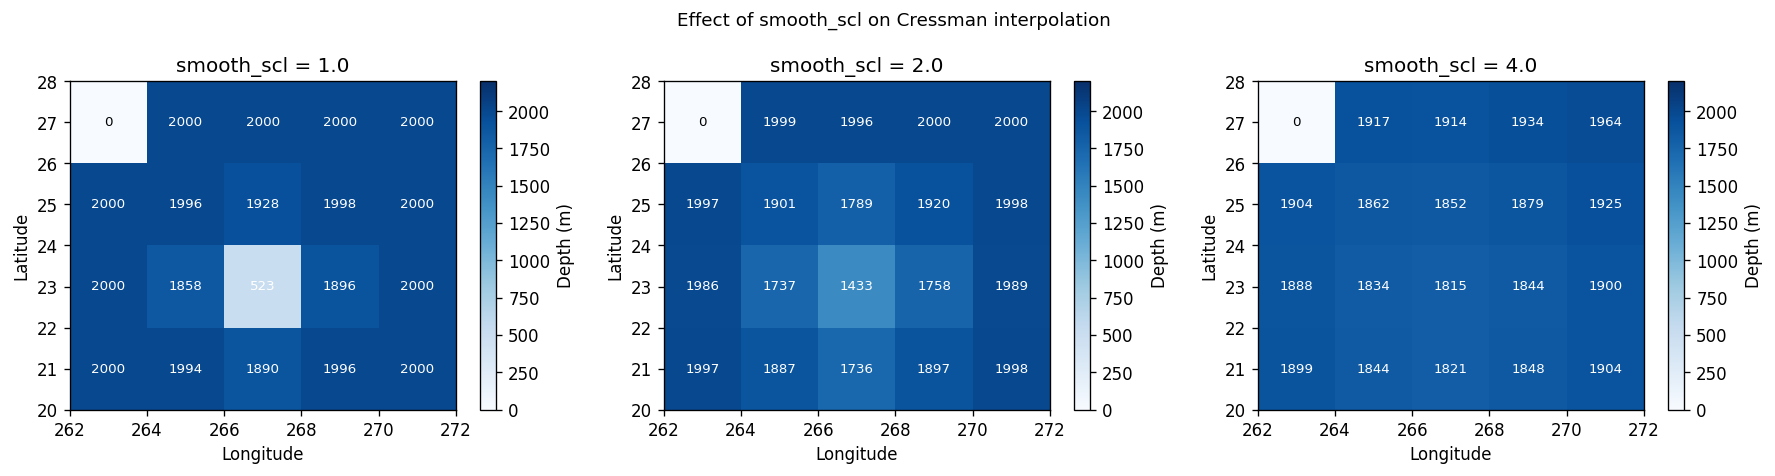

In [11]:
weights_path = tmp_dir / "cressman_weights.nc"
topo.cressman_interp(src, mask, smooth_scl=2.0, cressman_exp=2.0, weights_path=weights_path)

# Compare smooth_scl values
results = {}
for smooth_scl in [1.0, 2.0, 4.0]:
    t = Topo(grid, min_depth=5.0, version_control_dir=tmp_dir)
    t.set_flat(1000)
    wp = tmp_dir / f"weights_{smooth_scl}.nc"
    t.cressman_interp(src, mask, smooth_scl=smooth_scl, weights_path=wp)
    results[smooth_scl] = t.depth.values.copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (sscl, depth) in zip(axes, results.items()):
    c = ax.pcolormesh(grid.qlon.values, grid.qlat.values, depth,
                      cmap="Blues", vmin=0, vmax=2200, shading="flat")
    plt.colorbar(c, ax=ax, label="Depth (m)")
    for j in range(grid.ny):
        for i in range(grid.nx):
            ax.text(grid.tlon.values[j,i], grid.tlat.values[j,i],
                    f"{depth[j,i]:.0f}",
                    ha="center", va="center", fontsize=8,
                    color="white" if depth[j,i] > 500 else "k")
    ax.set_title(f"smooth_scl = {sscl}")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

plt.suptitle("Effect of smooth_scl on Cressman interpolation", fontsize=11)
plt.tight_layout()
plt.show()

Higher `smooth_scl` averages over more source pixels — useful for very coarse grids but can smooth out real bathymetric features. The tx2_3 default is `smooth_scl=2.0`.

## Summary

The Cressman pipeline in Python:

1. **Convert source ocean pixels to 3D Cartesian** — enables correct great-circle distance without wraparound issues
2. **Build `cKDTree`** on ocean pixels only — `O(log n)` radius queries instead of rectangular patch search
3. **For each ocean model cell**: query all source pixels within `L`, compute Cressman weights, normalise
4. **Assemble sparse matrix `S`** — apply as `S @ depth_source` for fast regridding
5. **Write weights to ESMF netCDF** — can be cached and reused
6. **Iterative neighbour fill** — fallback for cells with no source coverage
7. **Enforce `hmin`** — shallow ocean cells clamped to `min_depth`

**Next:** `11_full_scale_example.ipynb` — production workflow with real GEBCO data.